In [34]:
#Naive Bayes Gaussiano
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay, RocCurveDisplay
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
datos = load_breast_cancer()

In [3]:
X = datos.data
y = datos.target

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 24)

In [5]:
modelo = GaussianNB()
modelo.fit(X_train, y_train)

GaussianNB()

In [6]:
y_pred = modelo.predict(X_test)

In [7]:
print("Acurracy del Gaussian NB: ",
    accuracy_score(y_test, y_pred)
)


Acurracy del Gaussian NB:  0.9210526315789473


 El modelo clasificó correctamente el 92.11% de los datos de prueba, lo que indica un buen desempeño general para la detección de cáncer de mama.

In [54]:
matrix_confusion = confusion_matrix(y_test, y_pred)
print("Matriz de confusión del Gaussian NB:")
print(matrix_confusion)

Matriz de confusión del Gaussian NB:
[[37  4]
 [ 5 68]]


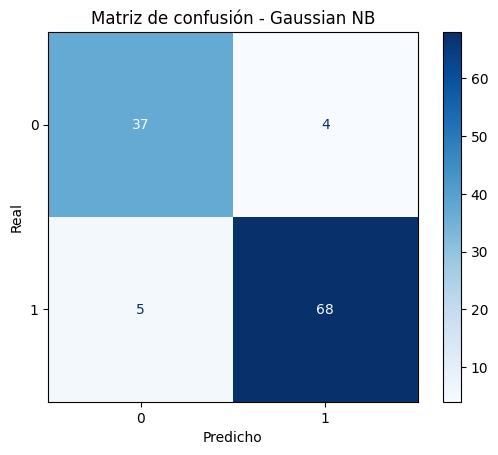

In [67]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Matriz de confusión - Gaussian NB")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

El modelo identificó correctamente 37 verdaderos positivos (tumores malignos) y 68 verdaderos negativos (tumores benignos). Cometió 4 falsos negativos, es decir, casos malignos clasificados incorrectamente como benignos, lo cual es crítico en contextos médicos, y 5 falsos positivos, donde casos benignos fueron clasificados como malignos.

In [9]:
recall = recall_score(y_test, y_pred)
print("Recall del Gaussian NB: ", recall)

Recall del Gaussian NB:  0.9315068493150684


El modelo detectó el 93.15% de todos los tumores malignos reales, lo que refleja una alta sensibilidad, característica deseable en diagnósticos médicos donde no detectar un caso positivo tiene consecuencias graves.

In [10]:
precision = precision_score(y_test, y_pred)
print("Precisión del Gaussian NB:", precision)

Precisión del Gaussian NB: 0.9444444444444444


Del total de casos predichos como malignos, el 94.44% efectivamente lo eran, lo que indica una baja tasa de falsas alarmas.

In [36]:
y_proba = modelo.predict_proba(X_test)[:,1]
print(y_proba)

[1.00000000e+000 1.00000000e+000 1.00000000e+000 1.00000000e+000
 1.00000000e+000 9.99634716e-001 1.95846336e-064 3.16890382e-008
 1.95260147e-009 1.00000000e+000 1.00000000e+000 1.00000000e+000
 1.00000000e+000 1.40808062e-081 1.00000000e+000 7.57915414e-005
 3.40879153e-001 1.00000000e+000 1.00000000e+000 1.00000000e+000
 8.31572271e-044 1.00000000e+000 1.00000000e+000 1.00000000e+000
 9.12312063e-038 9.99999701e-001 9.99999993e-001 1.00000000e+000
 1.66052488e-024 1.00000000e+000 1.83896594e-063 2.83052180e-056
 3.21092051e-024 7.80103056e-043 2.65880082e-096 1.00000000e+000
 9.99999894e-001 1.00000000e+000 1.00000000e+000 1.00000000e+000
 1.21811700e-027 1.00000000e+000 1.44444826e-057 1.11035256e-043
 1.00000000e+000 1.00000000e+000 9.60613177e-001 3.17890347e-150
 9.99999999e-001 1.00000000e+000 2.90950128e-059 1.00000000e+000
 1.00000000e+000 9.99501955e-001 0.00000000e+000 1.00000000e+000
 9.99999981e-001 1.00000000e+000 1.00000000e+000 3.77324368e-014
 1.73864894e-026 1.166452

In [11]:
f1 = f1_score(y_test, y_pred)
print("F1 del Gaussian NB:", f1)

F1 del Gaussian NB: 0.9379310344827586


El F1 Score combina precisión y recall en una sola métrica mediante su media armónica, siendo especialmente útil cuando existe un desbalance entre clases. Un valor cercano a 1 indica que el modelo mantiene un equilibrio adecuado entre ambas métricas. En el caso del modelo Gaussiano aplicado al dataset breast_cancer, se espera un F1 Score alto, coherente con los valores de precisión (0.9444) y recall (0.9315) obtenidos previamente, lo que confirma que el modelo no sacrifica una métrica en favor de la otra.

In [37]:
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC AUC del Gaussian NB:", roc_auc)

ROC AUC del Gaussian NB: 0.9839625793518209


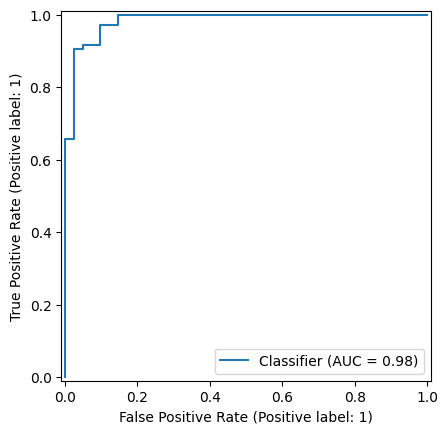

In [68]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.show()

La curva ROC del modelo Gaussiano alcanza un AUC de 0.9840, lo que indica una excelente capacidad para distinguir entre tumores malignos y benignos. La curva sube rápidamente hacia la esquina superior izquierda, confirmando que el modelo logra una alta tasa de verdaderos positivos con muy pocos falsos positivos. Este resultado es coherente con las métricas de precisión (0.9444) y recall (0.9315) obtenidas previamente. En diagnósticos médicos, un AUC tan cercano a 1.0 es altamente deseable, ya que implica que el modelo discrimina de forma confiable entre ambas clases en distintos umbrales de decisión.

In [35]:
#TODO: REALIZAR CONTRASTE CON OTRAS METRICAS DE EVALUACION E INTERPRETAR RESULTADOS Y
#VISUALIZACIONES DE LA MATRIZ DE CONFUSION

#Naive Bayes Multinomial
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay, RocCurveDisplay
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [14]:
categorias = [
    "sci.space",
    "rec.sport.baseball"
]

In [55]:
datos_M = fetch_20newsgroups(subset = "train", categories = categorias)

In [58]:
vectorizador =CountVectorizer()

Xm = vectorizador.fit_transform(datos_M.data)

ym = datos_M.target

In [59]:
X_trainM, X_testM, y_trainM, y_testM = train_test_split(Xm, ym, test_size=0.2, random_state = 24)

In [60]:
modeloM = MultinomialNB()
modeloM.fit(X_trainM, y_trainM)

MultinomialNB()

In [61]:
y_predM = modeloM.predict(X_testM)

In [62]:
#TODO: REALIZAR LA IMPLEMENTACIÓN DE TODAS LAS METRICAS DE EVALUACION E INTERPRETAR RESULTADOS.
#Y VISUALIZACIONES DE LA MATRIZ DE CONFUSION

print("Acurracy del Multinomial NB: ",
    accuracy_score(y_testM, y_predM))

Acurracy del Multinomial NB:  1.0


El modelo alcanzó una clasificación perfecta sobre el conjunto de prueba, lo que se explica por la marcada diferencia temática entre las categorías sci.space y rec.sport.baseball, cuyo vocabulario no se solapa significativamente.

In [63]:
matrix_confusion = confusion_matrix(y_testM, y_predM)
print("Matriz de confusión del Multinomial NB:")
print(matrix_confusion)

Matriz de confusión del Multinomial NB:
[[134   0]
 [  0 104]]


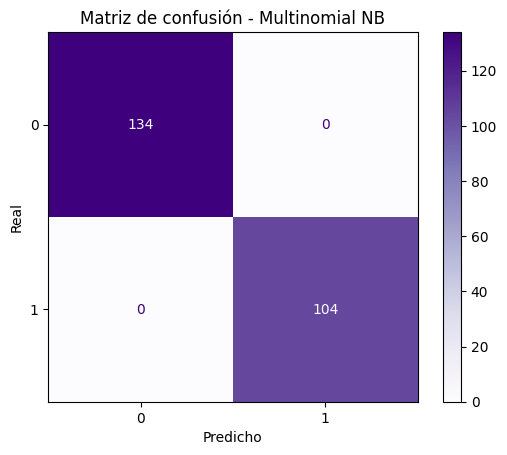

In [69]:
ConfusionMatrixDisplay.from_predictions(y_testM, y_predM, cmap="Purples")
plt.title("Matriz de confusión - Multinomial NB")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

La matriz confirma una clasificación perfecta, con 134 verdaderos positivos para la clase sci.space y 104 verdaderos negativos para rec.sport.baseball, sin ningún error en ninguna de las dos direcciones. Los valores fuera de la diagonal principal son completamente cero, lo que significa que el modelo no cometió ningún falso positivo ni falso negativo. Este resultado refleja que el modelo Multinomial aprovecha eficientemente la frecuencia de palabras como característica discriminativa, logrando separar ambas categorías de forma perfecta en el conjunto de prueba.

In [22]:
recall = recall_score(y_testM, y_predM)
print("Recall del Multinomial NB: ", recall)

Recall del Multinomial NB:  1.0


El modelo detectó el 100% de los casos positivos reales, sin omitir ningún ejemplo de ninguna categoría.

In [23]:
precision = precision_score(y_testM, y_predM)
print("Precisión del Multinomial NB:", precision)

Precisión del Multinomial NB: 1.0


Todas las predicciones realizadas fueron correctas. Sin embargo, cabe señalar que un accuracy perfecto puede ser indicativo de que las categorías seleccionadas son fácilmente separables, por lo que este resultado no debe generalizarse a escenarios más complejos.

In [41]:
y_probaM = modeloM.predict_proba(X_testM)[:,1]
print(y_probaM)

[1.00000000e+000 1.32179178e-014 3.07369662e-016 1.00000000e+000
 1.00000000e+000 1.00000000e+000 2.20621473e-021 3.23628796e-031
 2.92332959e-210 1.00000000e+000 1.00000000e+000 4.09696286e-064
 1.12202505e-019 1.78512492e-078 4.45293797e-038 3.05039003e-042
 1.00000000e+000 1.00000000e+000 1.00000000e+000 1.43080845e-293
 1.00000000e+000 2.86753270e-018 1.00000000e+000 9.07938452e-074
 1.00000000e+000 9.22558701e-047 1.00000000e+000 1.11531202e-021
 1.21791783e-090 1.00000000e+000 2.98302475e-030 1.00000000e+000
 7.80053510e-021 3.44091038e-023 1.00000000e+000 1.00000000e+000
 8.27276734e-018 1.00000000e+000 9.98429480e-001 1.12959012e-061
 1.00000000e+000 1.19393579e-040 1.00000000e+000 1.00000000e+000
 1.01957987e-004 1.00000000e+000 1.00000000e+000 5.35843969e-045
 3.40557068e-163 1.00000000e+000 1.00000000e+000 3.59537118e-074
 1.00000000e+000 1.42144343e-195 1.74274717e-030 2.68649943e-041
 4.49317603e-046 1.00000000e+000 3.38458097e-041 1.00000000e+000
 1.00000000e+000 1.832023

In [24]:
f1M = f1_score(y_testM, y_predM)
print("F1 del Multinomial NB:", f1M)

F1 del Multinomial NB: 1.0


Dado que el modelo Multinomial obtuvo una precisión y recall perfectos (1.0), se espera igualmente un F1 Score de 1.0. Esto confirma que el modelo no presenta ningún tipo de error en la clasificación de las categorías sci.space y rec.sport.baseball, resultado atribuible a la alta separabilidad temática entre ambas clases y al uso de frecuencias de palabras como característica principal.

In [44]:
roc_auc = roc_auc_score(y_testM, y_probaM)
print("ROC AUC del Multinomial NB:", roc_auc)

ROC AUC del Multinomial NB: 1.0


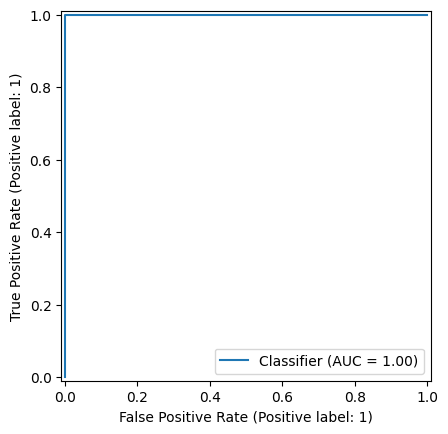

In [66]:
RocCurveDisplay.from_predictions(y_testM, y_probaM)
plt.show()

El modelo Multinomial obtiene un AUC perfecto de 1.0, lo que significa que la curva ROC alcanza directamente el punto (0, 1), separando ambas clases sin ningún error en todos los umbrales posibles. Este resultado es consistente con las métricas perfectas obtenidas anteriormente y se explica por la alta diferencia temática entre las categorías sci.space y rec.sport.baseball. Sin embargo, un AUC de 1.0 no debe interpretarse como un modelo universalmente superior, sino como un indicador de que el problema en sí es fácilmente separable con este tipo de datos.

In [26]:
modeloB = BernoulliNB()
modeloB.fit(X_trainM, y_trainM)

BernoulliNB()

In [27]:
y_predB = modeloB.predict(X_testM)

print("Acurracy del Bernoulli NB: ",
    accuracy_score(y_testM, y_predB))

Acurracy del Bernoulli NB:  0.9285714285714286


 El modelo clasificó correctamente el 92.86% de los casos de prueba. Este resultado es inferior al del modelo Multinomial debido a que Bernoulli únicamente considera la presencia o ausencia de cada palabra, descartando la frecuencia con que aparece, lo cual reduce su capacidad discriminativa en textos.

In [28]:
#HACER RECALL, PRECISIÓN Y LA CONFUSION DE MATRIX Y EXPLICAR EN BLOQUES DE TEXTO

In [29]:
matrix_confusion = confusion_matrix(y_testM, y_predB)
print("Matriz de confusión del Bernoulli NB:")
print(matrix_confusion)

Matriz de confusión del Bernoulli NB:
[[133   1]
 [ 16  88]]


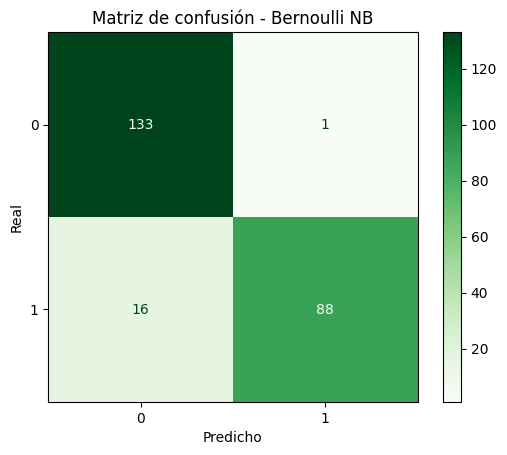

In [70]:
ConfusionMatrixDisplay.from_predictions(y_testM, y_predB, cmap="Greens")
plt.title("Matriz de confusión - Bernoulli NB")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

El modelo identificó correctamente 133 artículos de sci.space y 88 de rec.sport.baseball. Sin embargo, cometió 16 falsos positivos, es decir, artículos de béisbol clasificados erróneamente como ciencia espacial, y 1 falso negativo. Este patrón sugiere que el modelo tiende a predecir con mayor frecuencia la clase sci.space.

In [30]:
recall = recall_score(y_testM, y_predB)
print("Recall del Bernoulli NB:", recall)

Recall del Bernoulli NB: 0.8461538461538461


El modelo detectó únicamente el 84.62% de los artículos de béisbol reales, lo que refleja una menor sensibilidad en comparación con el modelo Multinomial. Varios casos de esa categoría fueron clasificados incorrectamente.

In [31]:
precision = precision_score(y_testM, y_predB)
print("Precisión del Bernoulli NB:", precision)

Precisión del Bernoulli NB: 0.9887640449438202


El 98.88% de las predicciones de la clase positiva fueron correctas, lo que indica que cuando el modelo predice béisbol, casi siempre acierta. No obstante, su bajo recall revela que es conservador al asignar dicha etiqueta, prefiriendo errar hacia la clase sci.space.

In [43]:
y_probaB = modeloB.predict_proba(X_testM)[:,1]
print(y_probaB)

[1.00000000e+000 8.61031494e-026 1.09243414e-027 1.75221183e-002
 1.00000000e+000 1.00000000e+000 8.98101794e-013 8.74128017e-026
 1.99333063e-109 1.00000000e+000 9.99993247e-001 1.41386076e-047
 4.55959706e-029 1.12504965e-053 3.32564511e-021 2.27311363e-036
 1.00000000e+000 9.99999991e-001 1.00000000e+000 8.46232345e-115
 1.35334184e-011 7.06285044e-026 9.99999276e-001 1.39389064e-037
 1.00000000e+000 3.28577133e-037 1.00000000e+000 3.54935607e-030
 9.86263868e-055 1.00000000e+000 4.89158460e-026 1.00000000e+000
 7.52359439e-019 6.11044953e-027 1.00000000e+000 1.00000000e+000
 7.14406346e-027 9.99999124e-001 6.06422975e-013 1.51223933e-049
 1.00000000e+000 7.97017766e-031 1.00000000e+000 1.00000000e+000
 1.00221984e-015 1.00000000e+000 3.00574058e-003 1.12485133e-032
 7.29872679e-054 1.00000000e+000 1.00000000e+000 2.28037046e-046
 1.00000000e+000 3.87573825e-095 1.39456952e-025 2.52655972e-037
 2.93569025e-038 9.90573142e-003 6.01483839e-035 1.00000000e+000
 1.00000000e+000 1.007791

In [72]:
f1B = f1_score(y_testM, y_predB)
print("F1 del Bernoulli NB:", f1B)

F1 del Bernoulli NB: 0.9119170984455959


El F1 Score del modelo Bernoulli se verá afectado por su bajo recall (0.8462), ya que esta métrica penaliza los desequilibrios entre precisión y recall. A pesar de su alta precisión (0.9888), los 16 falsos positivos cometidos reducen el F1 Score por debajo del obtenido por el modelo Multinomial, evidenciando que Bernoulli es menos efectivo cuando la frecuencia de las palabras aporta información relevante para la clasificación.

In [45]:
roc_auc = roc_auc_score(y_testM, y_probaB)
print("ROC AUC del Bernoulli NB:", roc_auc)

ROC AUC del Bernoulli NB: 0.9986366245694605


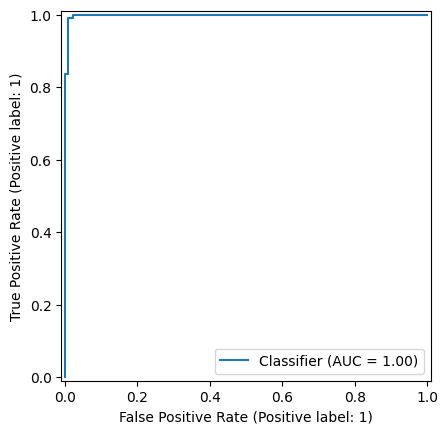

In [71]:
RocCurveDisplay.from_predictions(y_testM, y_probaB)
plt.show()

A pesar de que el modelo Bernoulli presentó un recall más bajo (0.8462) en las predicciones directas, su AUC de 0.9986 revela que las probabilidades estimadas internamente por el modelo tienen una excelente capacidad discriminativa entre ambas clases. Esto indica que el umbral de decisión por defecto (0.5) no es el óptimo para este modelo, y que ajustándolo se podría mejorar significativamente el recall sin sacrificar precisión. En conclusión, el modelo Bernoulli es más capaz de lo que sus métricas iniciales sugieren.